In [16]:
import torch
import neml2
import matplotlib.pyplot as plt
from pyzag import nonlinear, reparametrization, chunktime
import numpy as np
from scipy.optimize import brentq

In [17]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [18]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=1.0e6):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

In [19]:
nmodel = neml2.load_model("model_validation.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_a", "E_b", "E_c", "G_A", "G_bottom_A", "athermal_alpha", "athermal_b",
                                                                            "nu_a", "nu_b", "nu_c", "flow_rate_b", "shear_eff_m", "yield_sy", "v_disl_p",
                                                                            "v_disl_q", "v_disl_tau_p", "v_disl_H_0"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: athermal_alpha [Scalar][Double][cuda:0]
            athermal_b [Scalar][Double][cuda:0]
            athermal_shear_modulus [Scalar][Double][cuda:0]
            elasticity_E [Scalar][Double][cuda:0]
            elasticity_nu [Scalar][Double][cuda:0]
            flow_rate_b [Scalar][Double][cuda:0]
            kinharden_C [Scalar][Double][cuda:0]
           

In [24]:
nrate = 3
ntemp = 6
nbatch = nrate * ntemp
max_strain = 0.1
ntime = 100

temperatures = torch.tensor([77, 200, 300, 500, 700, 1000], device=device)
rates = torch.tensor([6.4e-2, 6.4e-3, 6.4e-4], device=device)

time = torch.zeros((ntime, nrate, ntemp, 1), device=device)
temperature = torch.zeros((ntime, nrate, ntemp, 1), device=device)
loading = torch.zeros((ntime, nrate, ntemp, 6), device=device)

for i, rate in enumerate(rates):
    time[:, i] = torch.linspace(0.0, max_strain/rate, ntime, device=device)[:, None, None]
    loading[...,0] = torch.linspace(0.0, max_strain, ntime, device=device)[:, None, None]
for i, T, in enumerate(temperatures):
    temperature[:, :, i] = T
time = time.reshape((ntime, -1, 1))
temperature = temperature.reshape((ntime, -1, 1))
loading = loading.reshape((ntime, -1, 6))

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


--- Full Input Tensors ---
time: torch.Size([100, 18, 1])
temperature: torch.Size([100, 18, 1])
loading: torch.Size([100, 18, 6])


In [25]:
with torch.no_grad():
    stress = model(time, temperature, loading)

/home/colinmg/anaconda3/envs/neml2/lib/python3.12/site-packages/pyzag/chunktime.py:114: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


In [9]:
v_disl_model = neml2.load_model("model_validation.i", "v_disl")

In [5]:
model_buffers = []
for bname, bvalue, in nmodel.named_buffers().items():
    model_buffers.append((bvalue.torch()))

a = model_buffers[0]
b = model_buffers[1]
h = model_buffers[2]
k_B = model_buffers[3]
L = 1/torch.sqrt(rho_L)

Bk = nmodel.Bk.torch().item()
H_0 = nmodel.H_0.torch().item()
T_0 = nmodel.T_0.torch().item()
p = nmodel.p.torch().item()
q = nmodel.q.torch().item()
s = nmodel.s.torch().item()
tau_p = nmodel.tau_p.torch().item()

# Lines commented out to remove sigmoid correction
K = (h * L * b) / (torch.pow(a, 2) * Bk)
tau_eff_analytical = torch.maximum(tau_eff.reshape(-1), torch.zeros_like(tau_eff.reshape(-1)))
tau_1 = torch.maximum(tau_eff_analytical - tau_a, torch.zeros_like(tau_eff.reshape(-1)))
tau_tilda = tau_1 / tau_p
# sig_core = -s * temperatures
# sig_exp = torch.exp(sig_core)
# phi = 1 / (1 + sig_exp)
# eps = 1.0e-6
# tau_th = phi * tau_1 + (1.0 - phi) * eps * tau_p
# tau_ratio = tau_th / tau_p
tau_ratio_safe = torch.minimum(torch.pow(tau_tilda, p), torch.ones_like(tau_tilda))
inner = 1.0 - tau_ratio_safe
delta_G = H_0 * (torch.pow(inner, q) - temperatures / T_0)
exp_core = -delta_G / (k_B * temperatures)
exp_val = torch.exp(exp_core)
v_kp = K * tau_eff_analytical * exp_val
# v_drag = tau_eff_analytical * b / Bk
# v_harm = (v_kp * v_drag) / (v_kp + v_drag + 1.0e-8)
# v_disl_analytical = phi * v_harm

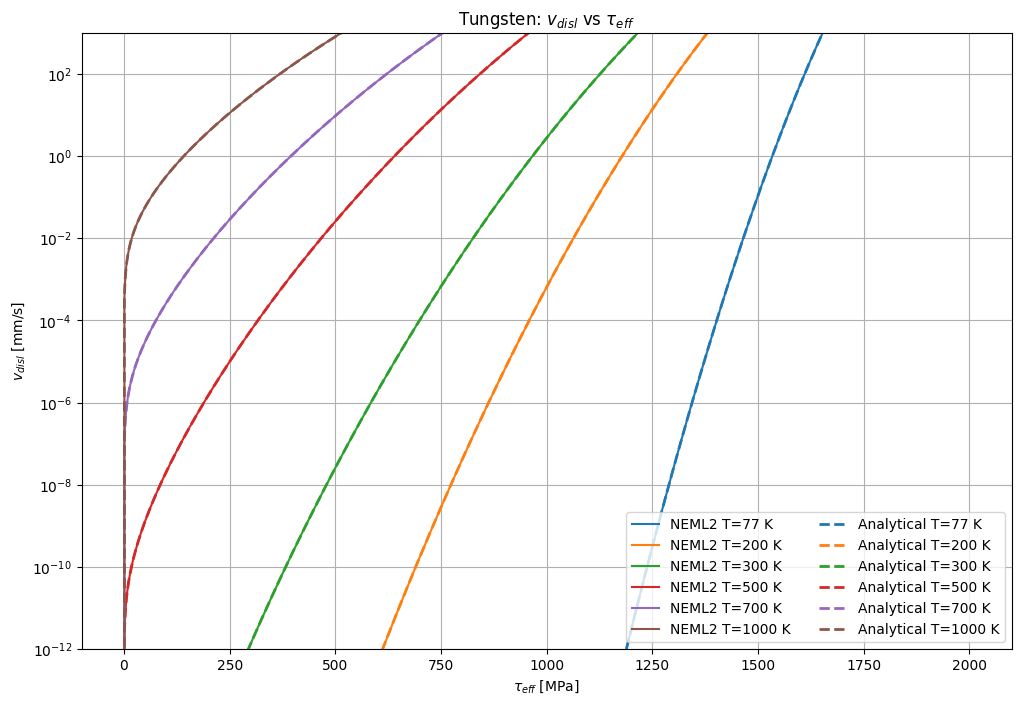

In [6]:
plt.figure(figsize=(12,8))
for i, T in enumerate(temperatures):
    plt.plot(tau_eff.reshape(-1).cpu().numpy(), v_disl[i].cpu().numpy(), color=f"C{i}", label=f"NEML2 T={T.item()} K")
for i, T in enumerate(temperatures):
    plt.plot(tau_eff_analytical.cpu().numpy(), v_kp[i].cpu().numpy(), "--", color=f"C{i}", lw=2, label=f"Analytical T={T.item()} K")
plt.xlabel(r"$\tau_{eff}$ [MPa]")
plt.ylabel(r"$v_{disl}$ [mm/s]")
plt.yscale("log")
plt.ylim([1e-12,1e3])
plt.title(r"Tungsten: $v_{disl}$ vs $\tau_{eff}$")
plt.grid()
plt.legend(ncol=2)
plt.show()


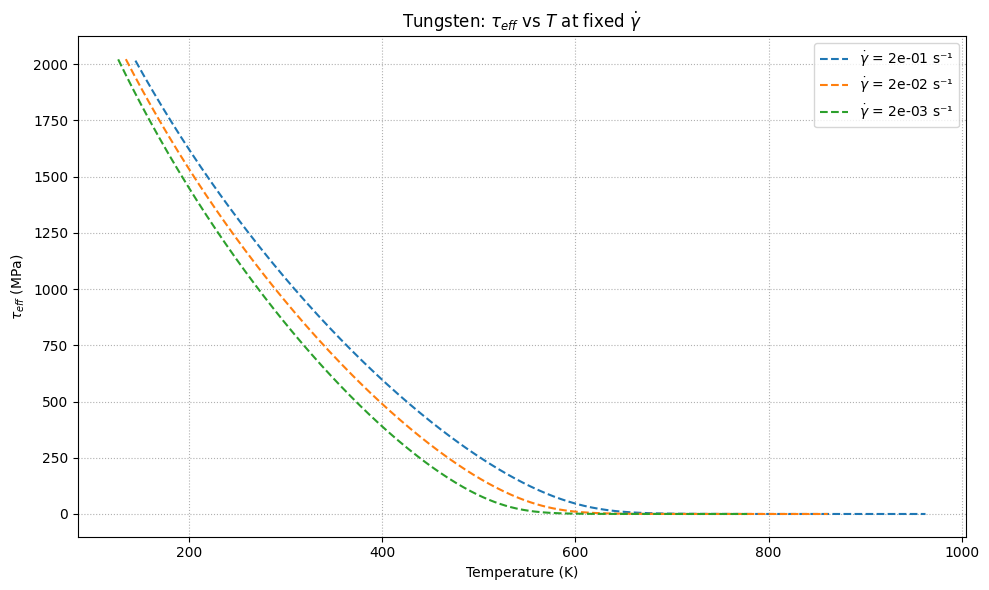

In [8]:
rho_m = torch.tensor([1.0e6], device=device)
gamma_dot = b * rho_m * v_disl
gamma_dot_analytical = b * rho_m * v_kp

def v_disl_scalar(tau_eff_val, T_val):
    """Returns scalar v_disl (mm/s) for a single tau_eff, T pair."""
    tau_1     = tau_eff_val - tau_a.item()
    sig_core  = -s * T_val
    phi       = 1.0 / (1.0 + np.exp(sig_core))
    eps       = 1e-6
    tau_th    = phi * tau_1 + (1.0 - phi) * eps * tau_p
    tau_ratio = tau_th / tau_p
    inner     = 1.0 - tau_ratio**p
    # clamp inner to avoid nan from negative base with fractional exponent
    inner     = max(inner, 0.0)
    delta_G   = H_0 * (inner**q - T_val / T_0)
    kT        = k_B.item() * T_val
    exp_val   = np.exp(-delta_G / kT)
    L         = 1.0 / np.sqrt(rho_L.item())
    K         = (h.item() * L * b.item()) / (a.item()**2 * Bk)
    v_kp      = K * tau_eff_val * exp_val
    v_drag    = tau_eff_val * b.item() / Bk
    v_harm    = (v_kp * v_drag) / (v_kp + v_drag + 1e-8)
    return phi * v_harm

def gamma_dot_scalar(tau_eff_val, T_val):
    """gamma_dot = rho_L * b * v_disl."""
    return rho_L.item() * b.item() * v_disl_scalar(tau_eff_val, T_val)

def invert_tau_eff(gamma_dot_target, T_val, tau_lo=1e-3, tau_hi=None):
    """
    Find tau_eff such that gamma_dot(tau_eff, T_val) == gamma_dot_target.
    Returns NaN if no solution exists in the bracket.
    """
    if tau_hi is None:
        tau_hi = tau_p - 1e-3          # just inside the Peierls stress

    f_lo = gamma_dot_scalar(tau_lo, T_val) - gamma_dot_target
    f_hi = gamma_dot_scalar(tau_hi, T_val) - gamma_dot_target

    if f_lo * f_hi > 0:               # root not bracketed → no solution
        return np.nan

    return brentq(
        lambda tau: gamma_dot_scalar(tau, T_val) - gamma_dot_target,
        tau_lo, tau_hi,
        xtol=1e-6, rtol=1e-8, maxiter=200
    )

T_sweep      = np.linspace(10, 1000, 500)           # K
gamma_targets = [2.04e-1, 2.04e-2, 2.04e-3]

fig, ax = plt.subplots(figsize=(10, 6))

for gd in gamma_targets:
    tau_curve = np.array([invert_tau_eff(gd, T) for T in T_sweep])
    ax.plot(T_sweep, tau_curve, '--', label=rf"$\dot{{\gamma}}$ = {gd:.0e} s⁻¹")

ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$\tau_{eff}$ (MPa)")
ax.set_title(r"Tungsten: $\tau_{eff}$ vs $T$ at fixed $\dot{\gamma}$")
ax.legend()
ax.grid(ls=":")
plt.tight_layout()
plt.show()
